In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/jvierstra/proj/vinson")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
from matplotlib import rcParams

from torch.utils.data import DataLoader
#from torchdata.stateful_dataloader import StatefulDataLoader

from torchinfo import summary
from tqdm import tqdm
from genome_tools.data.anndata import read_zarr_backed

rcParams["font.sans-serif"] = ["IBM Plex Sans"]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
def log_zscore_normalization(x, eta=1e-8):
    x = np.log(x + eta)
    return (x - x.mean()) / x.std()

def load_embeddings(filepath, motif_metadata_file):
    props = pd.read_table(filepath, index_col=0)
    metadata = pd.read_table(motif_metadata_file, index_col=0)
    props["cluster"] = metadata["cluster"]
    
    embeds = props.groupby(by="cluster").median().apply(log_zscore_normalization, axis=0)
    
    return embeds.T

embeddings = load_embeddings(
    "/net/seq/data2/projects/aabisheva/DHS_evolution/benchmark/hg38/tf_motif_v24_v2_regulome_all_0.01fdr/results/normalized/motif_proportions.tsv",
    "/net/seq/data2/projects/sabramov/ENCODE4/motifs_metadata.annotated.defunc.use_config.tsv"
)

embeddings.to_csv("../data/embeddings.tsv", index=True, header=True, sep="\t")

# Testing dataloader, model & loss function

In [3]:
from vinson.datasets.sequence import SequenceEmbedDataset
from vinson.models.sequence import BassetTrunkEmbed, CellEmbedding, EmbedModel
from vinson.loss import PoissonNLL

# Create trunk model
embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

#Create model
model = EmbedModel(trunk_model, embed_model, regression=True)

In [4]:
summary(model)

Layer (type:depth-idx)                   Param #
EmbedModel                               --
├─BassetTrunkEmbed: 1-1                  --
│    └─Sequential: 2-1                   --
│    │    └─Conv1d: 3-1                  23,100
│    │    └─BatchNorm1d: 3-2             600
│    │    └─ReLU: 3-3                    --
│    │    └─MaxPool1d: 3-4               --
│    └─ReLU: 2-2                         --
│    └─Sequential: 2-3                   --
│    │    └─Conv1d: 3-5                  660,200
│    │    └─BatchNorm1d: 3-6             400
│    │    └─ReLU: 3-7                    --
│    │    └─MaxPool1d: 3-8               --
│    └─ReLU: 2-4                         --
│    └─Sequential: 2-5                   --
│    │    └─Conv1d: 3-9                  280,200
│    │    └─BatchNorm1d: 3-10            400
│    │    └─ReLU: 3-11                   --
│    │    └─MaxPool1d: 3-12              --
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       51,400
│    └

### Simulate the loss function

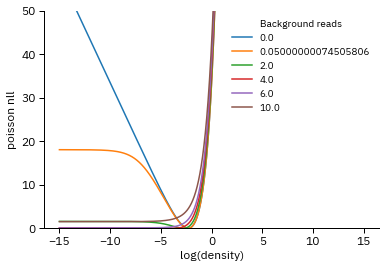

In [5]:
density = torch.tensor(0.1)
read_depth = torch.tensor(50e6)
bg_reads = torch.tensor([0, .05, 2, 4, 6, 10])

d = torch.linspace(-15, 15, 10_000)

for i in bg_reads:
    log_pred_counts = torch.logaddexp(d - torch.log(torch.tensor(1e6)) + torch.log(read_depth), torch.log(i))
    target_counts = density / 1e6 * read_depth

    loss = PoissonNLL(reduction="none")(log_pred_counts, target_counts)

    plt.plot(d, loss, label=f"{i}")

plt.ylim(0, 50)

plt.xlabel("log(density)")
plt.ylabel("poisson nll")


plt.legend(title="Background reads")

### Load in dataset and dataloader

In [6]:
samples_file = "/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/OCT8/epoch_1/data_OCT8_pos.batch1.train.h5"
negative_samples_file = "/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/OCT8/epoch_1/data_OCT8_neg.batch1.train.bed.gz"

# samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/AUG3/epoch_1/data_AUG3_pos.batch1.val.h5"
# negative_samples_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/AUG3/epoch_1/data_AUG3_neg.batch1.val.bed.gz"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"
sample_genotype_file = (
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/meta+sample_ids.tsv"
)
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/all_variants_stats.bed.gz"

# General dataset params
dataset_kwargs = dict(
    negative_samples_rate=2,
    sample_genotype_file=sample_genotype_file,
    genotype_file=genotype_file,
    reverse_complement=False,
    jitter=0,
    noise=0,
)

dataset = SequenceEmbedDataset(
    samples_file,
    embeddings_file,
    fasta_file,
    negative_samples_file=negative_samples_file,
    **dataset_kwargs,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

## Load model checkpoint

In [176]:
# Create trunk model
embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

model_predict = EmbedModel.load_from_checkpoint("../models/data_OCT8_with_warmup_and_decay_v2/checkpoints/last.ckpt", trunk=trunk_model, embed=embed_model)
model_predict = model_predict.eval()

### Predict variants (random batch)

In [180]:
import logging
logging.getLogger().setLevel(logging.INFO)

batch = next(iter(dataloader))

X_seq, X_embed, indicator, density, bg, read_depth, sample_id, chrom, mid, weight = (
    batch["ohe_seq"],
    batch["embed"],
    batch["indicator"],
    batch["density"],
    batch["bg"],
    batch["read_depth"],
    batch["sample_id"],
    batch["chrom"],
    batch["mid"],
    batch["weight"],
)

INFO:root:No INDIV_ID for AG95983 samples to genotype file (indiv_id = NaN). (chr19:4639963-4641307)
INFO:root:AG71636 not found in samples to genotype file. (chr1:36787167-36788511)
INFO:root:No INDIV_ID for AG72832 samples to genotype file (indiv_id = NaN). (chr4:142402938-142404282)
INFO:root:No INDIV_ID for AG72832 samples to genotype file (indiv_id = NaN). (chr7:142696302-142697646)
INFO:root:AG71620 not found in samples to genotype file. (chr14:68510242-68511586)
INFO:root:No INDIV_ID for AG15857 samples to genotype file (indiv_id = NaN). (chr16:2177894-2179238)
INFO:root:No INDIV_ID for AG95983 samples to genotype file (indiv_id = NaN). (chr5:168793830-168795174)
INFO:root:AG71547 not found in samples to genotype file. (chr7:136685034-136686378)
INFO:root:AG71647 not found in samples to genotype file. (chr15:57506916-57508260)
INFO:root:AG62303 not found in samples to genotype file. (chr2:7660954-7662298)
INFO:root:AG62376 not found in samples to genotype file. (chr11:14904319-1

In [181]:
y_ = model_predict(X_seq, X_embed).squeeze().detach()

ps = torch.tensor(1e-6)

dens_min = 0.01

log_pred_counts = torch.logaddexp(y_ - torch.log(torch.tensor(1e6)) + torch.log(read_depth), torch.log(bg + ps))
log_pred_counts = log_pred_counts.detach()

target_counts = (density / 1e6 * read_depth) + ps
target_counts = target_counts.detach()

pred_total_density = log_pred_counts.exp() / read_depth * 1e6

loss = PoissonNLL(reduction="none")(log_pred_counts, target_counts)
loss *= weight

print(f"loss = {loss.mean()}")

density = torch.max(density, torch.tensor(dens_min))

loss = 14.4200439453125


#### Predicted vs. observed read counts

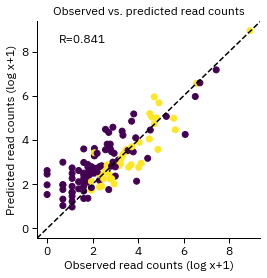

In [189]:
x = (target_counts + 1).log()
y = torch.logaddexp(log_pred_counts, torch.tensor(1).log())

plt.scatter(
    x,
    y,
    c=indicator,
)

plt.axline((0, 0), slope=1, color="k", ls="--")

plt.xlabel("Observed read counts (log x+1)")
plt.ylabel("Predicted read counts (log x+1)")

pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted read counts")

plt.gcf().set_size_inches(4, 4)

Text(0.5, 1.0, 'Observed vs. predicted density')

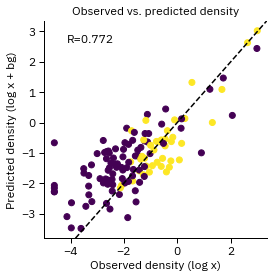

In [190]:
x = (density).log()
y = pred_total_density.log()

plt.scatter(x, y, c=indicator)
plt.gcf().set_size_inches(4, 4)

plt.axline((0, 0), slope=1, color="k", ls="--")

plt.xlabel("Observed density (log x)")
plt.ylabel("Predicted density (log x + bg)")


pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted density")

#### Predicted vs. observed peak densities

Text(0, 0.5, 'Peak density')

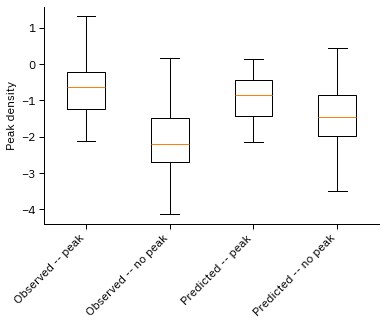

In [195]:
pred_w_peak = pred_total_density.log()[indicator.to(bool)]
pred_wo_peak = pred_total_density.log()[~indicator.to(bool)]


obs_w_peak = (density).log()[indicator.to(bool)]
obs_wo_peak = (density).log()[~indicator.to(bool)]

y = [
    obs_w_peak,
    obs_wo_peak,
    pred_w_peak,
    pred_wo_peak,
]

b = plt.boxplot(y, showfliers=False)

plt.xticks(
    np.arange(len(y)) + 1,
    labels=[
        "Observed -- peak",
        "Observed -- no peak",
        "Predicted -- peak",
        "Predicted -- no peak",
    ],
    rotation=45,
    ha="right",
)

plt.ylabel("Peak density")

#### Loss landscape

Text(0.5, 1.0, 'Loss landscape for batch')

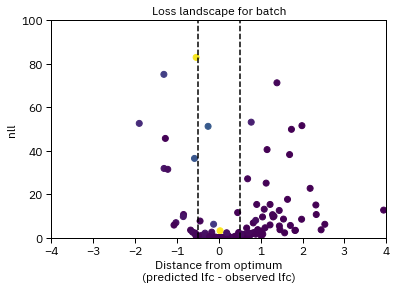

In [196]:
lfc = (torch.log(pred_total_density) - torch.log(density))

ax = plt.gca()

ax.scatter(lfc, loss, label="delta NLL", c=density)
ax.axvline(-0.5, color="k", ls="--")
ax.axvline(0.5, color="k", ls="--")

plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
ax.set_ylabel("nll")

ax.set_xlim(-4, 4)
ax.set_ylim(0, 100)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Loss landscape for batch")

#### Prediction error by peak density

Text(0.5, 1.0, 'Model prediction error by peak density')

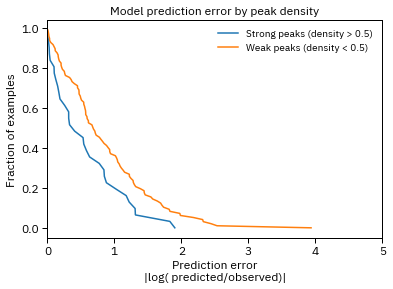

In [197]:
lfc_abs = lfc.abs()

x = lfc_abs[density > 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Strong peaks (density > 0.5)")

x = lfc_abs[density < 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Weak peaks (density < 0.5)")

plt.xlabel("Prediction error\n|log( predicted/observed)|")
plt.ylabel("Fraction of examples")

plt.legend()

plt.xlim(0, 5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Model prediction error by peak density")

(array([ 2.,  0.,  0.,  3.,  3.,  1.,  2.,  4.,  7.,  7., 10., 13.,  9.,
         3., 12.,  7., 10.,  6.,  6.,  4.,  5.,  4.,  2.,  2.,  1.,  2.,
         2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-2.74425173, -2.50355601, -2.26286054, -2.02216482, -1.78146923,
        -1.54077351, -1.30007792, -1.0593822 , -0.8186866 , -0.57799095,
        -0.33729532, -0.09659969,  0.14409596,  0.38479158,  0.62548721,
         0.86618286,  1.10687852,  1.34757411,  1.58826983,  1.82896543,
         2.06966114,  2.31035662,  2.55105233,  2.79174805,  3.03244352,
         3.27313924,  3.51383495,  3.75453067,  3.99522614,  4.23592186,
         4.47661734,  4.71731329,  4.95800877,  5.19870424,  5.4394002 ,
         5.68009567]),
 <BarContainer object of 35 artists>)

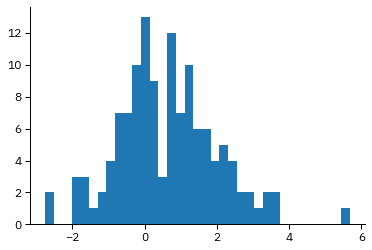

In [194]:
plt.hist(lfc)

### Contribution scores

In [156]:
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.models.helpers import _Exp

class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super(Wrapper, self).__init__()
        self.model = model
        self.exp = _Exp()
    def forward(self, seq, embed):
        return self.exp(self.model(seq, embed))

model_wrapper = Wrapper(model)
model_wrapper = model_wrapper.eval()

In [150]:
print(torch.where(y_.exp() > 0.5))

(tensor([  0,   4,  13,  14,  17,  32,  38,  51,  58,  64,  66,  67,  87,  89,
         95,  97,  99, 100, 103, 106, 121]),)


In [157]:
i = 17
torch.exp(y_[i]), density[i]

(tensor(0.7427), tensor(3.7143))

In [158]:
# You to do this because dinucleotide shuffle cannot deal with ambiguous bases
_X = force_strict_ohe(X_seq[i : i + 1].clone())

Y_embed = X_embed[i : i + 1].clone()

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[5, :].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed_rand,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)


tensor([2.9802e-07, 5.9605e-08, 8.9407e-08, 2.9802e-08, 1.7881e-07, 0.0000e+00,
        2.3842e-07, 1.7881e-07, 5.9605e-08, 1.1921e-07, 2.9802e-08, 1.4901e-07,
        1.7881e-07, 1.7881e-07, 2.9802e-08, 4.1723e-07, 1.4901e-07, 2.9802e-08,
        1.1921e-07, 1.7881e-07], grad_fn=<AbsBackward0>)
tensor([2.6822e-07, 2.1234e-07, 1.8626e-07, 2.4587e-07, 4.4703e-08, 3.0175e-07,
        2.9802e-08, 3.7253e-07, 1.7881e-07, 2.0862e-07, 3.5763e-07, 1.4901e-08,
        3.8743e-07, 2.4959e-07, 3.1292e-07, 4.1723e-07, 2.9802e-07, 2.1607e-07,
        2.6822e-07, 1.1921e-07], grad_fn=<AbsBackward0>)


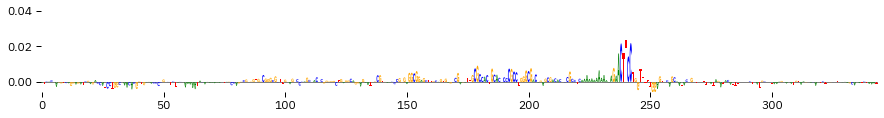

In [159]:
from tangermeme.plot import plot_logo

fig, ax = plt.subplots()
plot_logo(attrs[0][:, 500:-500], ax=ax)
ax.set_ylim(top=0.04)
fig.set_size_inches(15, 1.5)

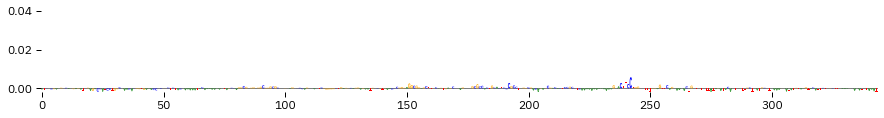

In [160]:
fig, ax = plt.subplots()
plot_logo(attrs_rand[0][:, 500:-500], ax=ax)
ax.set_ylim(top=0.04)
fig.set_size_inches(15, 1.5)

In [161]:
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise

In [50]:
Y_all = apply_pairwise(
    predict, 
    model_wrapper, 
    _X, #force_strict_ohe(X_seq), #_X, 
    args=(torch.as_tensor(dataset.embeddings_df.values),), device="cpu", verbose=True)


0it [00:00, ?it/s]/home/jvierstra/.local/miniconda3/envs/tf-2.13.0/lib/python3.9/site-packages/torch/amp/autocast_mode.py:283: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtype of torch.bfloat16, torch.float16 currently.
  warnings.warn(error_message)
4159it [00:54, 76.99it/s]


Text(0, 0.5, 'Number of samples')

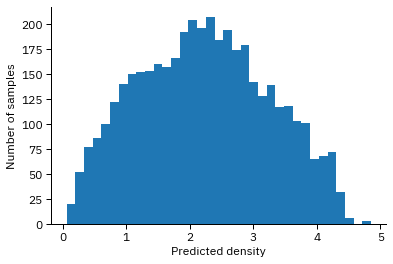

In [52]:
plt.hist(Y_all.squeeze())

plt.xlabel("Predicted density")
plt.ylabel("Number of samples")